In [42]:
import pandas as pd
import numpy as np

In [74]:
from google.colab import files
uploaded = files.upload()


Saving tag_relevance.dat to tag_relevance (1).dat
Saving movies.dat to movies (1).dat
Saving tags.dat to tags (1).dat


In [44]:
movies = pd.read_csv("movies.dat", sep="\t", header=None, names=['movieId', 'title', 'genres'])
tags = pd.read_csv("tags.dat", sep="\t", header=None, names=['tagId', 'tag', 'tagCount'])
tag_relevance = pd.read_csv("tag_relevance.dat", sep="\t", header=None, names=['movieId', 'tagId', 'relevance'])

In [45]:
print(movies.head())
print(tags.head())
print(tag_relevance.head())

   movieId                               title  genres
0        1                    Toy Story (1995)   53059
1        2                      Jumanji (1995)   22466
2        3             Grumpier Old Men (1995)   15111
3        4            Waiting to Exhale (1995)    2898
4        5  Father of the Bride Part II (1995)   14323
   tagId           tag  tagCount
0      0           007        61
1      1  007 (series)        24
2      2  18th century        37
3      3         1920s        42
4      4         1930s        55
   movieId  tagId  relevance
0        1      0      0.032
1        1      1      0.035
2        1      2      0.070
3        1      3      0.114
4        1      4      0.105


In [46]:
print(movies.shape)
print(tags.shape)
print(tag_relevance.shape)

(9734, 3)
(1128, 3)
(10979952, 3)


In [47]:
print("Movies")
movies.info()

print("\nTags")
tags.info()

print("\nTag Relevance")
tag_relevance.info()

Movies
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9734 entries, 0 to 9733
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9734 non-null   int64 
 1   title    9734 non-null   object
 2   genres   9734 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 228.3+ KB

Tags
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1128 entries, 0 to 1127
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   tagId     1128 non-null   int64 
 1   tag       1128 non-null   object
 2   tagCount  1128 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 26.6+ KB

Tag Relevance
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10979952 entries, 0 to 10979951
Data columns (total 3 columns):
 #   Column     Dtype  
---  ------     -----  
 0   movieId    int64  
 1   tagId      int64  
 2   relevance  float64
dtypes: float64(1), int64(2)
memory usage: 251.3

In [48]:
print("Movies")
print(movies.isnull().sum())

print("\nTags")
print(tags.isnull().sum())

print("\nTag Relevance")
print(tag_relevance.isnull().sum())

Movies
movieId    0
title      0
genres     0
dtype: int64

Tags
tagId       0
tag         0
tagCount    0
dtype: int64

Tag Relevance
movieId      0
tagId        0
relevance    0
dtype: int64


In [49]:
print("Movies:", movies.duplicated().sum())
print("Tags:", tags.duplicated().sum())
print("Tag Relevance:", tag_relevance.duplicated().sum())

Movies: 0
Tags: 0
Tag Relevance: 0


In [50]:
print(tag_relevance.describe())

            movieId         tagId     relevance
count  1.097995e+07  1.097995e+07  1.097995e+07
mean   2.050813e+04  5.635000e+02  1.164561e-01
std    2.836292e+04  3.256254e+02  1.574514e-01
min    1.000000e+00  0.000000e+00  0.000000e+00
25%    2.754000e+03  2.817500e+02  2.200000e-02
50%    5.539500e+03  5.635000e+02  5.400000e-02
75%    3.190300e+04  8.452500e+02  1.410000e-01
max    1.089320e+05  1.127000e+03  1.000000e+00


In [51]:
print("Total Movies:", movies['movieId'].nunique())

Total Movies: 9734


In [52]:
knn.fit(movie_features)

NearestNeighbors(algorithm='brute', metric='cosine')

In [53]:
print("Total Tags:", tags['tagId'].nunique())

Total Tags: 1128


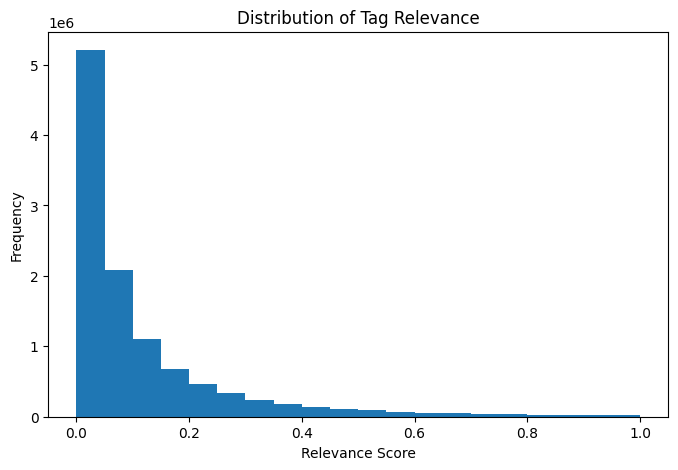

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(tag_relevance["relevance"], bins=20)
plt.title("Distribution of Tag Relevance")
plt.xlabel("Relevance Score")
plt.ylabel("Frequency")
plt.show()

In [55]:
movies = movies.drop_duplicates()
tags = tags.drop_duplicates()
tag_relevance = tag_relevance.drop_duplicates()

In [56]:
movies = movies.dropna()
tags = tags.dropna()
tag_relevance = tag_relevance.dropna()

In [57]:
movies.reset_index(drop=True, inplace=True)
tags.reset_index(drop=True, inplace=True)
tag_relevance.reset_index(drop=True, inplace=True)

In [58]:
print(movies.shape)
print(tags.shape)
print(tag_relevance.shape)

(9734, 3)
(1128, 3)
(10979952, 3)


In [59]:
movie_tags = pd.merge(
    tag_relevance,
    tags,
    on="tagId",
    how="left"
)

In [60]:
movie_tags = pd.merge(
    movie_tags,
    movies,
    on="movieId",
    how="left"
)

In [61]:
movie_tags.head()

,movieId,tagId,relevance,tag,tagCount,title,genres
0,1,0,0.032,007,61,Toy Story (1995),53059
1,1,1,0.035,007 (series),24,Toy Story (1995),53059
2,1,2,0.070,18th century,37,Toy Story (1995),53059
3,1,3,0.114,1920s,42,Toy Story (1995),53059
4,1,4,0.105,1930s,55,Toy Story (1995),53059


In [62]:
movie_tag_matrix = movie_tags.pivot_table(
    index="title",
    columns="tag",
    values="relevance",
    fill_value=0
)

In [63]:
movie_tag_matrix.head()

tag,007,007 (series),18th century,1920s,1930s,1950s,1960s,1970s,1980s,19th century,...,world politics,world war i,world war ii,writer's life,writers,writing,wuxia,wwii,zombie,zombies
title,,,,,,,,,,,,,,,,,,,,,
$9.99 (2008),0.020,0.029,0.022,0.049,0.052,0.057,0.011,0.294,0.096,0.020,...,0.021,0.130,0.018,0.222,0.173,0.043,0.007,0.012,0.062,0.014
'Round Midnight (1986),0.017,0.019,0.018,0.137,0.521,0.302,0.478,0.365,0.060,0.016,...,0.323,0.082,0.014,0.171,0.344,0.132,0.062,0.008,0.051,0.014
'Til There Was You (1997),0.046,0.062,0.029,0.034,0.049,0.035,0.060,0.092,0.043,0.028,...,0.030,0.016,0.011,0.026,0.431,0.179,0.016,0.009,0.106,0.014
"'burbs, The (1989)",0.038,0.040,0.024,0.041,0.109,0.095,0.036,0.113,0.377,0.027,...,0.030,0.019,0.012,0.041,0.299,0.058,0.019,0.009,0.137,0.019
'night Mother (1986),0.031,0.032,0.037,0.041,0.091,0.084,0.035,0.133,0.095,0.030,...,0.056,0.023,0.030,0.144,0.222,0.070,0.057,0.020,0.097,0.024


In [64]:
print(movie_tag_matrix.shape)

(9733, 1128)


In [65]:
from sklearn.preprocessing import normalize

movie_features = normalize(movie_tag_matrix)

In [66]:
from sklearn.metrics.pairwise import cosine_similarity

In [67]:
similarity = cosine_similarity(movie_features)

In [68]:
similarity.shape

(9733, 9733)

In [69]:
from sklearn.neighbors import NearestNeighbors

In [70]:
knn = NearestNeighbors(
    metric="cosine",
    algorithm="brute"
)

In [71]:
knn.fit(movie_features)

NearestNeighbors(algorithm='brute', metric='cosine')

In [72]:
def recommend(movie_name, n=10):

    if movie_name not in movie_tag_matrix.index:
        print("Movie not found")
        return

    index = movie_tag_matrix.index.get_loc(movie_name)

    distances, indices = knn.kneighbors(
        movie_features[index].reshape(1, -1),
        n_neighbors=n+1
    )

    print(f"\nRecommendations for {movie_name}\n")

    for i in range(1, len(indices[0])):
        print(movie_tag_matrix.index[indices[0][i]])

In [77]:
recommend("Cars (2006)")


Recommendations for Cars (2006)

Bug's Life, A (1998)
Ice Age (2002)
Bolt (2008)
Toy Story (1995)
Monsters, Inc. (2001)
Finding Nemo (2003)
Ratatouille (2007)
Wreck-It Ralph (2012)
Toy Story 2 (1999)
Antz (1998)


In [76]:
matching_movies = movies[movies['title'].str.contains('Cars', case=False, na=False)]
if not matching_movies.empty:
    print('Found these movies containing "Cars":')
    for title in matching_movies['title']:
        print(title)
else:
    print('No movie containing "Cars" found in the dataset.')

Found these movies containing "Cars":
Riding in Cars with Boys (2001)
Used Cars (1980)
Cars (2006)
Cars 2 (2011)
